In [1]:
import logging
import os
import sys
import numpy as np
import pandas as pd

# Define paths relative to the project root
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
LOG_FILE = os.path.join(ROOT_DIR, "part3_machine_learning", "ml_pipeline.log")

# Setup module-level logger
logger = logging.getLogger("supervised_learning")
logger.setLevel(logging.INFO)
logger.handlers.clear()

formatter = logging.Formatter(
    fmt="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)

# StreamHandler for console output
console_handler = logging.StreamHandler(sys.stdout)
console_handler.setFormatter(formatter)
console_handler.setLevel(logging.INFO)

# FileHandler in append mode
file_handler = logging.FileHandler(LOG_FILE, mode="a")
file_handler.setFormatter(formatter)
file_handler.setLevel(logging.INFO)

logger.addHandler(console_handler)
logger.addHandler(file_handler)
logger.propagate = False

logger.info(
    "Standard logging initialized for 01_supervised_learning.ipynb. Appending"
    f" to {LOG_FILE}"
)

2026-10-07 13:07:31 - INFO - supervised_learning - Standard logging initialized for 01_supervised_learning.ipynb. Appending to /Users/rakesh/Documents/CapstoneProject/SmartCityTrafficCapstone/part3_machine_learning/ml_pipeline.log


In [2]:
DATA_PATH = os.path.join(ROOT_DIR, "Metro_Interstate_Traffic_Volume.csv")

try:
  df = pd.read_csv(DATA_PATH)
  df["date_time"] = pd.to_datetime(df["date_time"])
  logger.info(
      f"Dataset loaded successfully from '{DATA_PATH}'. Total rows: {len(df)},"
      f" Columns: {len(df.columns)}"
  )
  print(f"Data shape: {df.shape}")
  display(df.head())
except Exception as e:
  logger.error(
      f"Failed to load dataset from '{DATA_PATH}'", exc_info=True
  )
  raise

2026-10-07 13:07:42 - INFO - supervised_learning - Dataset loaded successfully from '/Users/rakesh/Documents/CapstoneProject/SmartCityTrafficCapstone/Metro_Interstate_Traffic_Volume.csv'. Total rows: 48204, Columns: 9
Data shape: (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [ ]:
# Feature Engineering and Proxy Label Generation

# 1. Cyclical and Calendar Features
df["hour"] = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

# Cyclical encoding of hour and day of week
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24.0)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24.0)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7.0)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7.0)

# Holiday indicator
df["is_holiday"] = (df["holiday"].fillna("None") != "None").astype(int)

# 2. Weather Encodings
low_vis_conditions = ["Fog", "Mist", "Smoke", "Haze"]
severe_weather_conditions = ["Squall", "Thunderstorm", "Snow"]

df["is_low_visibility"] = df["weather_main"].isin(low_vis_conditions).astype(int)

# 3. Data-driven Congestion Category (Quartiles)
q1, q2, q3 = df["traffic_volume"].quantile([0.25, 0.5, 0.75]).values
logger.debug(f"Calculated traffic_volume quartiles -> Q1: {q1}, Q2: {q2}, Q3: {q3}")

def bucket_congestion(volume):
    if volume <= q1:
        return "Low"
    elif volume <= q2:
        return "Medium"
    elif volume <= q3:
        return "High"
    return "Severe"

df["congestion_category"] = df["traffic_volume"].apply(bucket_congestion)

# 4. Proxy Accident-Risk Label
high_congestion = df["congestion_category"].isin(["High", "Severe"])
risky_weather = (
    df["weather_main"].isin(severe_weather_conditions)
    | (df["is_low_visibility"] == 1)
)
df["high_risk"] = (high_congestion & risky_weather).astype(int)

# Temperature outlier check (handle 0 Kelvin if present)
if (df["temp"] == 0).any():
    median_temp = df.loc[df["temp"] > 0, "temp"].median()
    df["temp"] = df["temp"].replace(0, median_temp)
    logger.warning(f"Replaced 0 Kelvin anomalies with median temperature ({median_temp:.2f} K)")

logger.info(
    f"Engineered features completed. Total records: {len(df)}. "
    f"High-risk instances: {df['high_risk'].sum()} ({df['high_risk'].mean():.2%})"
)

# Display distribution summary
print("Congestion Category Distribution:")
print(df["congestion_category"].value_counts())
print("\nHigh Risk Target Distribution:")
print(df["high_risk"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

2026-10-07 13:17:05 - WARNING - supervised_learning - Replaced 0 Kelvin anomalies with median temperature (282.46 K)
2026-10-07 13:17:05 - INFO - supervised_learning - Engineered features completed. Total records: 48204. High-risk instances: 5436 (11.28%)
Congestion Category Distribution:
congestion_category
High      12058
Medium    12053
Low       12053
Severe    12040
Name: count, dtype: int64

High Risk Target Distribution:
high_risk
0    88.72%
1    11.28%
Name: proportion, dtype: object


In [ ]:
# Feature Matrix Preparation and Train-Test Splitting
from sklearn.model_selection import train_test_split

# 1. Continuous and numerical indicator features
numeric_features = [
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "is_weekend", "is_holiday", "temp", "rain_1h", 
    "snow_1h", "clouds_all", "is_low_visibility"
]

# 2. One-hot encoded weather categories (drop_first=True to avoid collinearity)
weather_encoded = pd.get_dummies(df["weather_main"], prefix="weather", drop_first=True)

# 3. Assemble Feature Matrix X
X = pd.concat([df[numeric_features], weather_encoded], axis=1)

# 4. Target variables
y_reg = df["traffic_volume"]
y_clf = df["high_risk"]

logger.info(f"Feature matrix X assembled. Shape: {X.shape}. Total features: {X.shape[1]}")

# 5. Regression Split (Standard 80/20)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.20, random_state=42
)
logger.info(
    f"Regression split complete -> Train shape: {X_train_reg.shape}, "
    f"Test shape: {X_test_reg.shape}"
)

# 6. Classification Split (Stratified 80/20)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)
logger.info(
    f"Classification split complete (stratified) -> Train shape: {X_train_clf.shape}, "
    f"Test shape: {X_test_clf.shape}"
)

print(f"Features (first 5 columns):\n{list(X.columns[:5])} ... and {len(X.columns) - 5} more.")
print(f"Regression split: Train={X_train_reg.shape[0]}, Test={X_test_reg.shape[0]}")
print(f"Classification split: Train={X_train_clf.shape[0]}, Test={X_test_clf.shape[0]}")

2026-10-07 13:32:58 - INFO - supervised_learning - Feature matrix X assembled. Shape: (48204, 21). Total features: 21
2026-10-07 13:32:58 - INFO - supervised_learning - Regression split complete -> Train shape: (38563, 21), Test shape: (9641, 21)
2026-10-07 13:32:59 - INFO - supervised_learning - Classification split complete (stratified) -> Train shape: (38563, 21), Test shape: (9641, 21)
Features (first 5 columns):
['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend'] ... and 16 more.
Regression split: Train=38563, Test=9641
Classification split: Train=38563, Test=9641


In [ ]:
# Regression Baseline - Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

logger.info("Initializing Regression Baseline: LinearRegression")

# 1. Instantiate and fit model on training data
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)

# 2. Predict on test set
y_pred_lr = lin_reg.predict(X_test_reg)

# 3. Calculate evaluation metrics
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
r2_lr = r2_score(y_test_reg, y_pred_lr)

# 4. Log results
logger.info(f"Linear Regression Results -> MAE: {mae_lr:.2f} vehicles, R2: {r2_lr:.4f}")

# Display results
print("========================================")
print("Linear Regression (Baseline) Performance")
print("========================================")
print(f"Mean Absolute Error (MAE) : {mae_lr:.2f} vehicles")
print(f"R-squared (R2 Score)      : {r2_lr:.4f}")

2026-10-07 13:35:42 - INFO - supervised_learning - Initializing Regression Baseline: LinearRegression
2026-10-07 13:35:42 - INFO - supervised_learning - Linear Regression Results -> MAE: 838.53 vehicles, R2: 0.7066
Linear Regression (Baseline) Performance
Mean Absolute Error (MAE) : 838.53 vehicles
R-squared (R2 Score)      : 0.7066


In [6]:
# Regression Ensemble - Random Forest Regressor
import joblib
from sklearn.ensemble import RandomForestRegressor

logger.info("Initializing Regression Ensemble: RandomForestRegressor (n_estimators=100, max_depth=15)")

# 1. Instantiate and train model
rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)
rf_reg.fit(X_train_reg, y_train_reg)

# 2. Predict on test set
y_pred_rf = rf_reg.predict(X_test_reg)

# 3. Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)
r2_rf = r2_score(y_test_reg, y_pred_rf)

# 4. Log results
logger.info(f"Random Forest Regressor Results -> MAE: {mae_rf:.2f} vehicles, R2: {r2_rf:.4f}")

# 5. Persist trained artifact
models_dir = os.path.join(ROOT_DIR, "part3_machine_learning", "models")
os.makedirs(models_dir, exist_ok=True)
rf_reg_path = os.path.join(models_dir, "best_regression_rf.pkl")
joblib.dump(rf_reg, rf_reg_path)
logger.info(f"Saved regression model artifact to '{rf_reg_path}'")

# Display comparison summary
print("==================================================")
print("Regression Model Comparison (Test Set)")
print("==================================================")
print(f"{'Metric':<25} | {'Baseline (Linear Reg)':<20} | {'Ensemble (Random Forest)':<20}")
print("-" * 72)
print(f"{'MAE (vehicles)':<25} | {mae_lr:<20.2f} | {mae_rf:<20.2f}")
print(f"{'R-squared (R2)':<25} | {r2_lr:<20.4f} | {r2_rf:<20.4f}")
print("==================================================")

2026-10-07 13:43:04 - INFO - supervised_learning - Initializing Regression Ensemble: RandomForestRegressor (n_estimators=100, max_depth=15)
2026-10-07 13:43:05 - INFO - supervised_learning - Random Forest Regressor Results -> MAE: 268.40 vehicles, R2: 0.9436
2026-10-07 13:43:05 - INFO - supervised_learning - Saved regression model artifact to '/Users/rakesh/Documents/CapstoneProject/SmartCityTrafficCapstone/part3_machine_learning/models/best_regression_rf.pkl'
Regression Model Comparison (Test Set)
Metric                    | Baseline (Linear Reg) | Ensemble (Random Forest)
------------------------------------------------------------------------
MAE (vehicles)            | 838.53               | 268.40              
R-squared (R2)            | 0.7066               | 0.9436              


In [7]:
# Classification Baseline - Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

logger.info("Initializing Classification Baseline: LogisticRegression (balanced)")

# 1. Instantiate and train baseline model
# StandardScaler is applied in-pipeline or via scaled numeric features for numerical convergence
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

log_clf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

log_clf_pipeline.fit(X_train_clf, y_train_clf)

# 2. Predict labels and probabilities on the stratified test set
y_pred_log = log_clf_pipeline.predict(X_test_clf)
y_proba_log = log_clf_pipeline.predict_proba(X_test_clf)[:, 1]

# 3. Calculate evaluation metrics
acc_log = accuracy_score(y_test_clf, y_pred_log)
prec_log = precision_score(y_test_clf, y_pred_log, zero_division=0)
rec_log = recall_score(y_test_clf, y_pred_log)
f1_log = f1_score(y_test_clf, y_pred_log)
auc_log = roc_auc_score(y_test_clf, y_proba_log)

# 4. Log baseline metrics
logger.info(
    f"Logistic Regression Results -> Accuracy: {acc_log:.4f}, Precision: {prec_log:.4f}, "
    f"Recall: {rec_log:.4f}, F1: {f1_log:.4f}, ROC AUC: {auc_log:.4f}"
)

# Display baseline report
print("==========================================")
print("Logistic Regression (Baseline) Performance")
print("==========================================")
print(f"Accuracy  : {acc_log:.4f}")
print(f"Precision : {prec_log:.4f}")
print(f"Recall    : {rec_log:.4f}")
print(f"F1-Score  : {f1_log:.4f}")
print(f"ROC AUC   : {auc_log:.4f}")

2026-10-07 13:44:57 - INFO - supervised_learning - Initializing Classification Baseline: LogisticRegression (balanced)
2026-10-07 13:44:58 - INFO - supervised_learning - Logistic Regression Results -> Accuracy: 0.9671, Precision: 0.7818, Recall: 0.9825, F1: 0.8708, ROC AUC: 0.9939
Logistic Regression (Baseline) Performance
Accuracy  : 0.9671
Precision : 0.7818
Recall    : 0.9825
F1-Score  : 0.8708
ROC AUC   : 0.9939


In [8]:
# Classification Ensemble - Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

logger.info("Initializing Classification Ensemble: RandomForestClassifier (n_estimators=100, max_depth=12)")

# 1. Instantiate and train ensemble classifier
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)
rf_clf.fit(X_train_clf, y_train_clf)

# 2. Predict labels and probabilities on test set
y_pred_rf_c = rf_clf.predict(X_test_clf)
y_proba_rf_c = rf_clf.predict_proba(X_test_clf)[:, 1]

# 3. Calculate evaluation metrics
acc_rf = accuracy_score(y_test_clf, y_pred_rf_c)
prec_rf = precision_score(y_test_clf, y_pred_rf_c, zero_division=0)
rec_rf = recall_score(y_test_clf, y_pred_rf_c)
f1_rf = f1_score(y_test_clf, y_pred_rf_c)
auc_rf = roc_auc_score(y_test_clf, y_proba_rf_c)

# 4. Log ensemble results
logger.info(
    f"Random Forest Classifier Results -> Accuracy: {acc_rf:.4f}, Precision: {prec_rf:.4f}, "
    f"Recall: {rec_rf:.4f}, F1: {f1_rf:.4f}, ROC AUC: {auc_rf:.4f}"
)

# 5. Persist trained artifact
rf_clf_path = os.path.join(models_dir, "best_classification_rf.pkl")
joblib.dump(rf_clf, rf_clf_path)
logger.info(f"Saved classification model artifact to '{rf_clf_path}'")

# Display comparison summary
print("========================================================================")
print("Classification Model Comparison (Test Set)")
print("========================================================================")
print(f"{'Metric':<15} | {'Baseline (Logistic Reg)':<25} | {'Ensemble (Random Forest)':<25}")
print("-" * 72)
print(f"{'Accuracy':<15} | {acc_log:<25.4f} | {acc_rf:<25.4f}")
print(f"{'Precision':<15} | {prec_log:<25.4f} | {prec_rf:<25.4f}")
print(f"{'Recall':<15} | {rec_log:<25.4f} | {rec_rf:<25.4f}")
print(f"{'F1-Score':<15} | {f1_log:<25.4f} | {f1_rf:<25.4f}")
print(f"{'ROC AUC':<15} | {auc_log:<25.4f} | {auc_rf:<25.4f}")
print("========================================================================")

2026-10-07 13:48:18 - INFO - supervised_learning - Initializing Classification Ensemble: RandomForestClassifier (n_estimators=100, max_depth=12)
2026-10-07 13:48:19 - INFO - supervised_learning - Random Forest Classifier Results -> Accuracy: 0.9844, Precision: 0.8934, Recall: 0.9788, F1: 0.9342, ROC AUC: 0.9971
2026-10-07 13:48:19 - INFO - supervised_learning - Saved classification model artifact to '/Users/rakesh/Documents/CapstoneProject/SmartCityTrafficCapstone/part3_machine_learning/models/best_classification_rf.pkl'
Classification Model Comparison (Test Set)
Metric          | Baseline (Logistic Reg)   | Ensemble (Random Forest) 
------------------------------------------------------------------------
Accuracy        | 0.9671                    | 0.9844                   
Precision       | 0.7818                    | 0.8934                   
Recall          | 0.9825                    | 0.9788                   
F1-Score        | 0.8708                    | 0.9342                 

2026-10-07 13:54:58 - INFO - supervised_learning - Generating feature importance visualizations for Supervised models.
2026-10-07 13:54:58 - INFO - supervised_learning - Feature importance figure saved to '/Users/rakesh/Documents/CapstoneProject/SmartCityTrafficCapstone/part3_machine_learning/feature_importance.png'


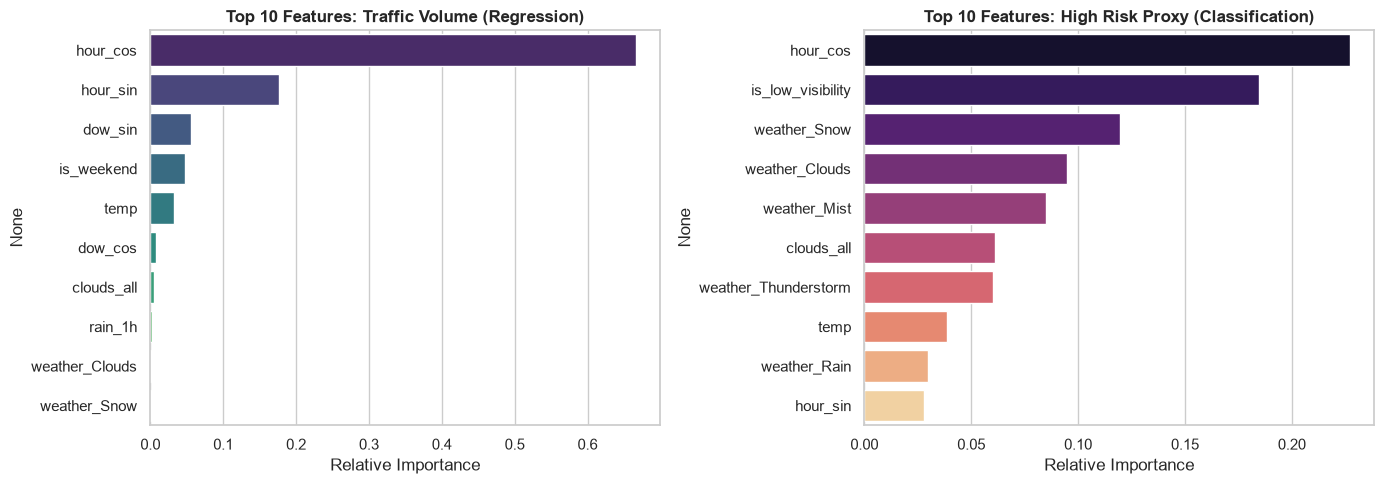

In [10]:
# Feature Importance Visualizations for Supervised Models
import matplotlib.pyplot as plt
import seaborn as sns

logger.info("Generating feature importance visualizations for Supervised models.")

# 1. Extract feature importances
reg_importances = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
clf_importances = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

# 2. Plot side-by-side bar plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Regression feature importances
sns.barplot(
    x=reg_importances.values,
    y=reg_importances.index,
    hue=reg_importances.index,
    legend=False,
    ax=axes[0],
    palette="viridis",
)
axes[0].set_title("Top 10 Features: Traffic Volume (Regression)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Relative Importance")

# Classification feature importances
sns.barplot(
    x=clf_importances.values,
    y=clf_importances.index,
    hue=clf_importances.index,
    legend=False,
    ax=axes[1],
    palette="magma",
)
axes[1].set_title("Top 10 Features: High Risk Proxy (Classification)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Relative Importance")

plt.tight_layout()

# 3. Save figure
figures_dir = os.path.join(ROOT_DIR, "part3_machine_learning")
fig_path = os.path.join(figures_dir, "feature_importance.png")
plt.savefig(fig_path, dpi=300)
logger.info(f"Feature importance figure saved to '{fig_path}'")

plt.show()

In [12]:
# Cell 10: Task 1 Final Summary & Audit Logging

logger.info("Task 1: Supervised Machine Learning completed successfully.")

summary_text = f"""
========================================================================
TASK 1: SUPERVISED MACHINE LEARNING SUMMARY REPORT
========================================================================

1. PREDICTING TRAFFIC VOLUME (Regression)
   - Baseline (Linear Regression)    : Average Error = {mae_lr:.2f} vehicles, R2 = {r2_lr:.4f}
   - Best Model (Random Forest)      : Average Error = {mae_rf:.2f} vehicles, R2 = {r2_rf:.4f}
   - Improvement                     : Prediction error dropped by {((mae_lr - mae_rf) / mae_lr) * 100:.1f}%
   - Saved File                      : models/best_regression_rf.pkl

2. IDENTIFYING HIGH-RISK CONDITIONS (Classification)
   - Baseline (Logistic Regression)  : Accuracy = {acc_log:.2%}, Catch Rate (Recall) = {rec_log:.2%}, F1 = {f1_log:.4f}
   - Best Model (Random Forest)      : Accuracy = {acc_rf:.2%}, Precision = {prec_rf:.2%}, Catch Rate (Recall) = {rec_rf:.2%}, F1 = {f1_rf:.4f}
   - Saved File                      : models/best_classification_rf.pkl

3. KEY TAKEAWAYS
   - Traffic volume follows clear 24-hour daily patterns and weekday routines (hour of day, day of week).
   - High-risk driving conditions are mostly triggered by poor visibility (fog, mist, haze) and winter weather (snow).
========================================================================
"""

print(summary_text)
logger.info("Summary report generated and verified.")

2026-10-07 14:00:23 - INFO - supervised_learning - Task 1: Supervised Machine Learning completed successfully.

TASK 1: SUPERVISED MACHINE LEARNING SUMMARY REPORT

1. PREDICTING TRAFFIC VOLUME (Regression)
   - Baseline (Linear Regression)    : Average Error = 838.53 vehicles, R2 = 0.7066
   - Best Model (Random Forest)      : Average Error = 268.40 vehicles, R2 = 0.9436
   - Improvement                     : Prediction error dropped by 68.0%
   - Saved File                      : models/best_regression_rf.pkl

2. IDENTIFYING HIGH-RISK CONDITIONS (Classification)
   - Baseline (Logistic Regression)  : Accuracy = 96.71%, Catch Rate (Recall) = 98.25%, F1 = 0.8708
   - Best Model (Random Forest)      : Accuracy = 98.44%, Precision = 89.34%, Catch Rate (Recall) = 97.88%, F1 = 0.9342
   - Saved File                      : models/best_classification_rf.pkl

3. KEY TAKEAWAYS
   - Traffic volume follows clear 24-hour daily patterns and weekday routines (hour of day, day of week).
   - High-ris